Packages

In [2]:
!pip -q install "matminer>=0.9" "pymatgen>=2023" "scikit-learn>=1.2" "tqdm" "numpy" "pandas"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 6.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 94.3 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 129.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 101.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 19.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 39.

In [3]:
!pip install matbench --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 7.7 MB/s eta 0:00:0000:0100:01m


In [4]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.structure.misc import StructureComposition
from matminer.featurizers.structure.matrix import SineCoulombMatrix

from matbench.bench import MatbenchBenchmark

## Dataset Exploration — matbench_perovskites

**18 928** DFT-computed perovskite structures (ABX₃ family) from the Matbench suite.

| Column | Description |
|--------|-------------|
| `structure` | Pymatgen `Structure` string — lattice parameters (a, b, c, angles), periodicity, and fractional coordinates of every site |
| `e_form` | **Formation energy** (eV/atom) — the prediction target. Lower values → thermodynamically more stable |
| `composition` | Chemical formula (derived from structure during featurisation) |
| `MagpieData …` | 132 composition-level descriptors from the Magpie preset (element statistics: mean, range, mode, … of properties like electronegativity, atomic weight, valence, etc.) |

In [7]:
from matbench.bench import MatbenchBenchmark
from pymatgen.core import Structure

# ---- Load dataset directly from matbench (no local CSV needed) ----
mb = MatbenchBenchmark(autoload=False, subset=["matbench_perovskites"])
task = list(mb.tasks)[0]
task.load()

# Grab the full dataset (fold 0 train+test covers everything; combine for exploration)
df_train = task.get_train_and_val_data(0, as_type="df")
df_test  = task.get_test_data(0, include_target=True, as_type="df")
df_raw   = pd.concat([df_train, df_test], ignore_index=True)

print(f"Dataset size: {len(df_raw):,} rows")
print(f"Columns: {list(df_raw.columns)}\n")

# ---- Pick a sample with 4 unique elements ----
for idx in range(len(df_raw)):
    struct = df_raw.loc[idx, "structure"]
    n_elems = len(set(str(s.specie) for s in struct))
    if n_elems == 4:
        sample_idx = idx
        break

sample_struct = df_raw.loc[sample_idx, "structure"]
formula = sample_struct.composition.reduced_formula
print(f"▸ Sample row (index {sample_idx}) — {formula}:\n")
print(sample_struct)
print(f"\ne_form (target) = {df_raw.loc[sample_idx, 'e_form']:.2f} eV/atom")
print("\n— 'structure' is a pymatgen Structure object: lattice constants (abc),")
print("  angles, periodic boundary conditions, and fractional coordinates")
print("  of each atomic site.")
print("— 'e_form' is the DFT formation energy we want to predict.")

2026-02-20 11:41:26 INFO     Initialized benchmark 'matbench_v0.1' with 1 tasks: 
['matbench_perovskites']


INFO:matbench:Initialized benchmark 'matbench_v0.1' with 1 tasks: 
['matbench_perovskites']


2026-02-20 11:41:26 INFO     Loading dataset 'matbench_perovskites'...


INFO:matbench.task:Loading dataset 'matbench_perovskites'...


Fetching matbench_perovskites.json.gz from https://ml.materialsproject.org/projects/matbench_perovskites.json.gz to /usr/local/lib/python3.12/dist-packages/matminer/datasets/matbench_perovskites.json.gz


Fetching https://ml.materialsproject.org/projects/matbench_perovskites.json.gz in MB: 4.194304MB [00:00, 490.14MB/s]                


2026-02-20 11:41:30 INFO     Dataset 'matbench_perovskites loaded.


INFO:matbench.task:Dataset 'matbench_perovskites loaded.


Dataset size: 18,928 rows
Columns: ['structure', 'e_form']

▸ Sample row (index 2) — ReAsO2F:

Full Formula (Re1 As1 O2 F1)
Reduced Formula: ReAsO2F
abc   :   4.292639   4.292639   4.292639
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (5)
  #  SP           a    b    c
---  ----  --------  ---  ---
  0  Re    0.141617  0    0
  1  As    0.509386  0.5  0.5
  2  F     0.531687  0    0.5
  3  O     0.307487  0.5  0
  4  O     0.927582  0.5  0.5

e_form (target) = 1.48 eV/atom

— 'structure' is a pymatgen Structure object: lattice constants (abc),
  angles, periodic boundary conditions, and fractional coordinates
  of each atomic site.
— 'e_form' is the DFT formation energy we want to predict.


In [10]:
df_raw.loc[sample_idx, "structure"]

Structure Summary
Lattice
    abc : 4.292638763849676 4.292638763849676 4.292638763849676
 angles : 90.0 90.0 90.0
 volume : 79.09937085444218
      A : np.float64(4.292638763849676) np.float64(0.0) np.float64(0.0)
      B : np.float64(0.0) np.float64(4.292638763849676) np.float64(0.0)
      C : np.float64(0.0) np.float64(0.0) np.float64(4.292638763849676)
    pbc : True True True
PeriodicSite: Re (0.6079, 0.0, 0.0) [0.1416, 0.0, 0.0]
PeriodicSite: As (2.187, 2.146, 2.146) [0.5094, 0.5, 0.5]
PeriodicSite: F (2.282, 0.0, 2.146) [0.5317, 0.0, 0.5]
PeriodicSite: O (1.32, 2.146, 0.0) [0.3075, 0.5, 0.0]
PeriodicSite: O (3.982, 2.146, 2.146) [0.9276, 0.5, 0.5]

In [11]:
df_raw.loc[sample_idx]

,2
structure,"[[0.60790913 0. 0. ] Re, [2.186..."
e_form,1.48


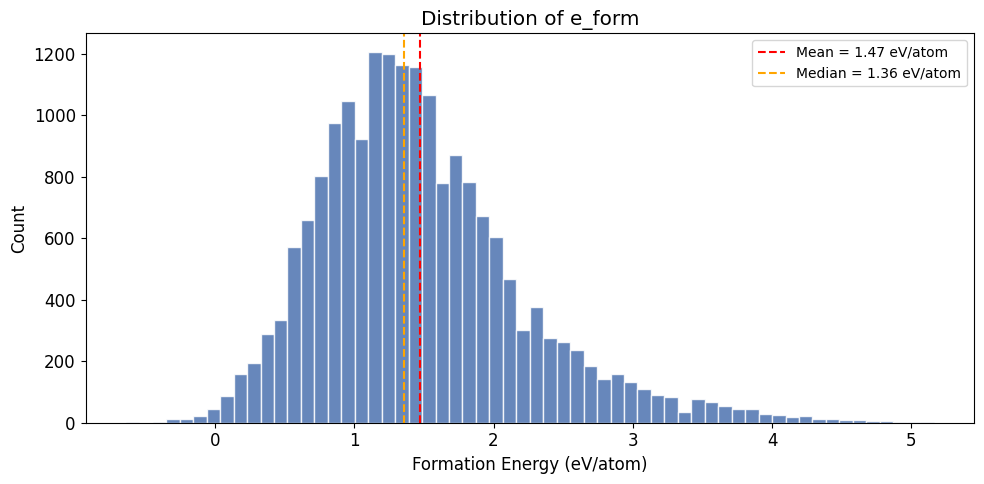


Summary stats:
count    18928.000000
mean         1.470932
std          0.742502
min         -0.640000
25%          0.960000
50%          1.360000
75%          1.840000
max          5.160000


In [15]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"font.size": 12})

fig, ax = plt.subplots(figsize=(10, 5))

# --- Histogram ---
ax.hist(df_raw["e_form"], bins=60, color="#4C72B0", edgecolor="white", alpha=0.85)
ax.axvline(df_raw["e_form"].mean(), color="red", ls="--", lw=1.5,
           label=f'Mean = {df_raw["e_form"].mean():.2f} eV/atom')
ax.axvline(df_raw["e_form"].median(), color="orange", ls="--", lw=1.5,
           label=f'Median = {df_raw["e_form"].median():.2f} eV/atom')
ax.set_xlabel("Formation Energy (eV/atom)")
ax.set_ylabel("Count")
ax.set_title("Distribution of e_form")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("e_form_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nSummary stats:\n{df_raw['e_form'].describe().to_string()}")

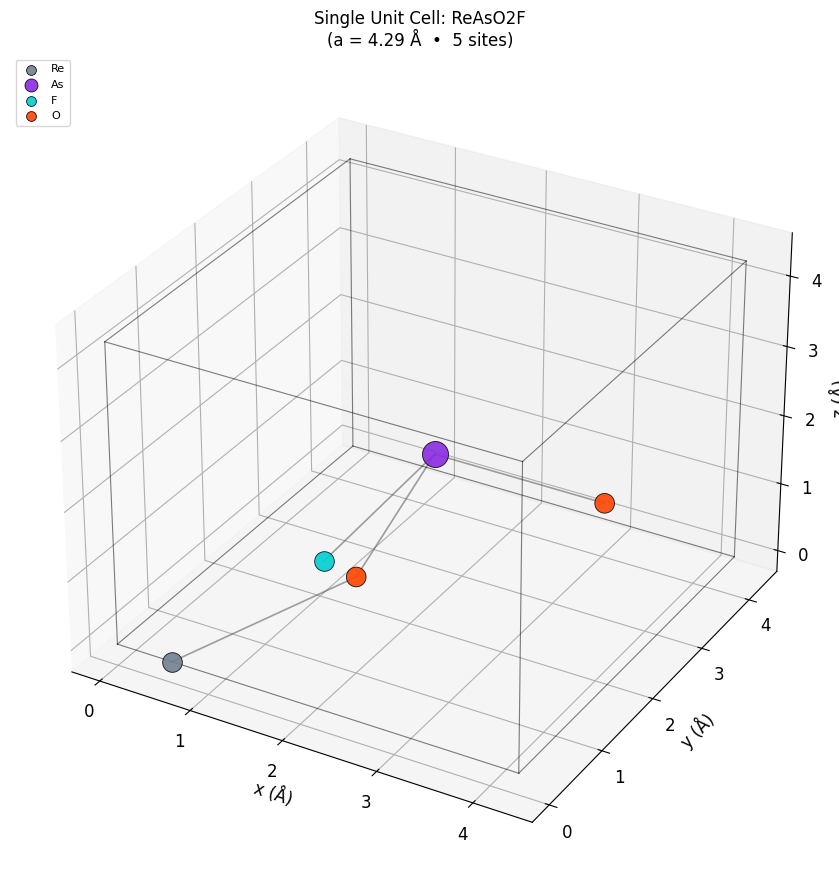

Formula: ReAsO2F  |  Sites: 5  |  Bonds: 4 (cutoff 2.42 Å)
e_form = 1.48 eV/atom


In [18]:
from mpl_toolkits.mplot3d import Axes3D
from itertools import product
from scipy.spatial.distance import cdist
import numpy as np

# ---------- Colour & size maps ----------
color_map = {
    "Rb": "#8B0000", "Sc": "#4682B4", "S": "#FFD700", "O": "#FF4500",
    "Re": "#708090", "As": "#8A2BE2", "F": "#00CED1", "Hf": "#556B2F",
    "Bi": "#C71585", "Te": "#2E8B57", "N": "#1E90FF", "Rh": "#B8860B",
    "Pt": "#C0C0C0", "C": "#333333", "Li": "#9ACD32", "Y": "#DAA520",
    "Sr": "#6A5ACD", "Ca": "#20B2AA", "Ba": "#FF69B4", "K": "#FF8C00",
    "Cs": "#4B0082", "Na": "#00BFFF", "Mg": "#32CD32", "Zr": "#A0522D",
    "Ti": "#808080", "V": "#9370DB", "Cr": "#BDB76B", "Mn": "#CD853F",
    "Fe": "#B22222", "Co": "#4169E1", "Ni": "#228B22", "Cu": "#B8860B",
    "Zn": "#708090", "Ga": "#DB7093", "Ge": "#8FBC8F", "Se": "#FF6347",
    "Br": "#A52A2A", "Mo": "#778899", "Ru": "#696969", "Pd": "#D2691E",
    "Ag": "#C0C0C0", "Cd": "#DEB887", "In": "#BC8F8F", "Sn": "#8B8682",
    "Sb": "#9932CC", "I": "#800080", "La": "#2F4F4F", "Ta": "#5F9EA0",
    "W": "#556B2F", "Ir": "#B0C4DE", "Au": "#FFD700", "Hg": "#AAAAAA",
    "Tl": "#9400D3", "Pb": "#708090", "Nb": "#6495ED", "Si": "#A9A9A9",
    "B": "#FF1493", "Be": "#7FFF00", "P": "#FFA500", "Cl": "#00FF7F",
    "Os": "#4682B4"}
size_map = {el: 600 if el in ("Rb","Cs","Ba","Sr","K") else
                400 if el in ("Sc","Y","La","Hf","Zr","Ti") else
                350 if el in ("S","Se","Te","P","As","Sb","Bi") else
                200 for el in color_map}

# ---------- Helper: draw a crystal structure on a 3D axis ----------
def draw_crystal(ax, crystal, struct_orig, title, show_subcell_grid=False):
    """Plot atoms, bonds, and unit-cell wireframe on a 3D matplotlib axis."""
    cart   = crystal.cart_coords
    elems  = [str(site.specie) for site in crystal]
    unique = list(dict.fromkeys(elems))

    # Bonds via distance cutoff
    dm = cdist(cart, cart)
    np.fill_diagonal(dm, np.inf)
    bond_cutoff = dm.min() * 1.35
    bonds = [(i, j) for i in range(len(cart)) for j in range(i+1, len(cart)) if dm[i,j] <= bond_cutoff]

    # Atoms
    for sp in unique:
        mask = [e == sp for e in elems]
        pts  = cart[mask]
        ax.scatter(pts[:,0], pts[:,1], pts[:,2],
                   s=size_map.get(sp, 300), color=color_map.get(sp, "grey"),
                   edgecolors="black", linewidths=0.6, label=sp, depthshade=True, alpha=0.9)

    # Bonds
    for i, j in bonds:
        ax.plot(*zip(cart[i], cart[j]), color="#555555", lw=1.2, alpha=0.55)

    # Wireframe — outer bounding box of crystal
    lat_c = crystal.lattice.matrix
    origin = np.zeros(3)
    corners = [origin, lat_c[0], lat_c[1], lat_c[2],
               lat_c[0]+lat_c[1], lat_c[0]+lat_c[2], lat_c[1]+lat_c[2],
               lat_c[0]+lat_c[1]+lat_c[2]]
    edge_idx = [(0,1),(0,2),(0,3),(1,4),(1,5),(2,4),(2,6),(3,5),(3,6),(4,7),(5,7),(6,7)]
    for ei, ej in edge_idx:
        ax.plot(*zip(corners[ei], corners[ej]), color="black", lw=0.8, ls="-", alpha=0.5)

    # Optional: draw original sub-cell grid inside the supercell
    if show_subcell_grid:
        lo = struct_orig.lattice.matrix
        n_rep = round((crystal.lattice.a / struct_orig.lattice.a))
        for dx, dy, dz in product(range(n_rep), repeat=3):
            shift = dx*lo[0] + dy*lo[1] + dz*lo[2]
            sc = [shift, shift+lo[0], shift+lo[1], shift+lo[2],
                  shift+lo[0]+lo[1], shift+lo[0]+lo[2],
                  shift+lo[1]+lo[2], shift+lo[0]+lo[1]+lo[2]]
            for ei, ej in edge_idx:
                ax.plot(*zip(sc[ei], sc[ej]), color="grey", lw=0.35, ls="--", alpha=0.35)

    ax.set_xlabel("x (Å)"); ax.set_ylabel("y (Å)"); ax.set_zlabel("z (Å)")
    ax.set_title(title, fontsize=12)
    ax.legend(loc="upper left", fontsize=8, markerscale=0.5)
    return len(bonds), bond_cutoff

# ---------- Prepare structures ----------
struct_orig = df_raw.loc[sample_idx, "structure"]
formula     = struct_orig.composition.reduced_formula
a_lat       = struct_orig.lattice.a

# ========== Plot 1: Single Unit Cell ==========
fig = plt.figure(figsize=(9, 9))
ax  = fig.add_subplot(111, projection="3d")
n1, bc1 = draw_crystal(ax, struct_orig.copy(), struct_orig,
    f"Single Unit Cell: {formula}\n(a = {a_lat:.2f} Å  •  {len(struct_orig)} sites)")
plt.tight_layout()
plt.show()

print(f"Formula: {formula}  |  Sites: {len(struct_orig)}  |  Bonds: {n1} (cutoff {bc1:.2f} Å)")
print(f"e_form = {df_raw.loc[sample_idx, 'e_form']:.2f} eV/atom")

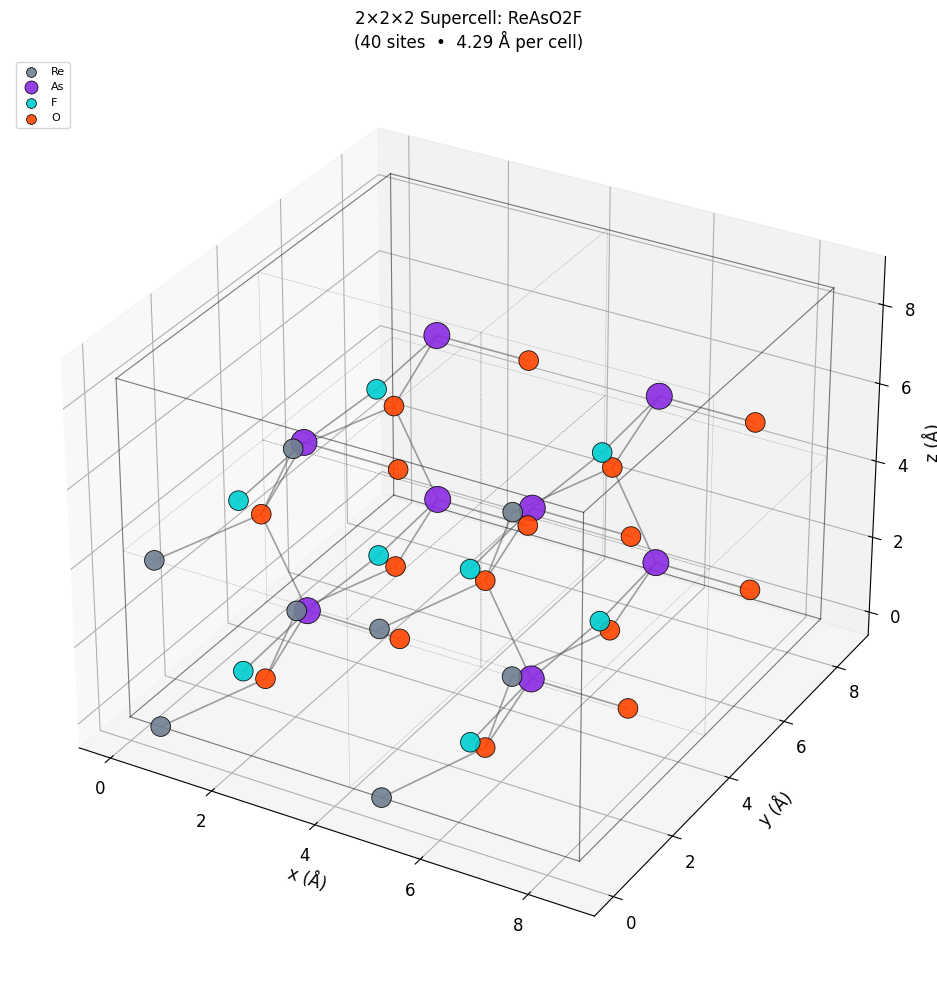

Formula: ReAsO2F  |  Supercell sites: 40  |  Bonds: 44 (cutoff 2.42 Å)
e_form = 1.48 eV/atom


In [19]:
# ========== Plot 2: 2×2×2 Supercell (periodic crystal) ==========
cell_2x = struct_orig.copy()
cell_2x.make_supercell([2, 2, 2])

fig = plt.figure(figsize=(10, 10))
ax  = fig.add_subplot(111, projection="3d")
n2, bc2 = draw_crystal(ax, cell_2x, struct_orig,
    f"2×2×2 Supercell: {formula}\n({len(cell_2x)} sites  •  {a_lat:.2f} Å per cell)",
    show_subcell_grid=True)
plt.tight_layout()
plt.show()

print(f"Formula: {formula}  |  Supercell sites: {len(cell_2x)}  |  Bonds: {n2} (cutoff {bc2:.2f} Å)")
print(f"e_form = {df_raw.loc[sample_idx, 'e_form']:.2f} eV/atom")

Row 1111: CuAsN2O  |  4 elements: ['Cu', 'As', 'N', 'O']
Lattice: a=3.851 Å  |  Sites: 5  |  e_form = 1.26 eV/atom



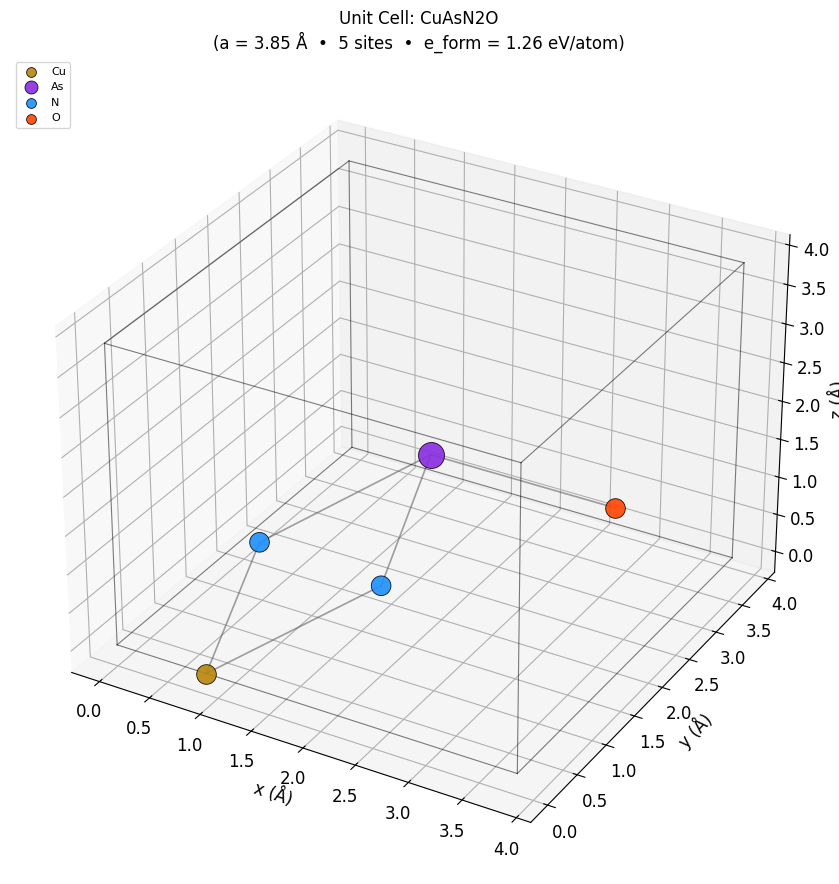

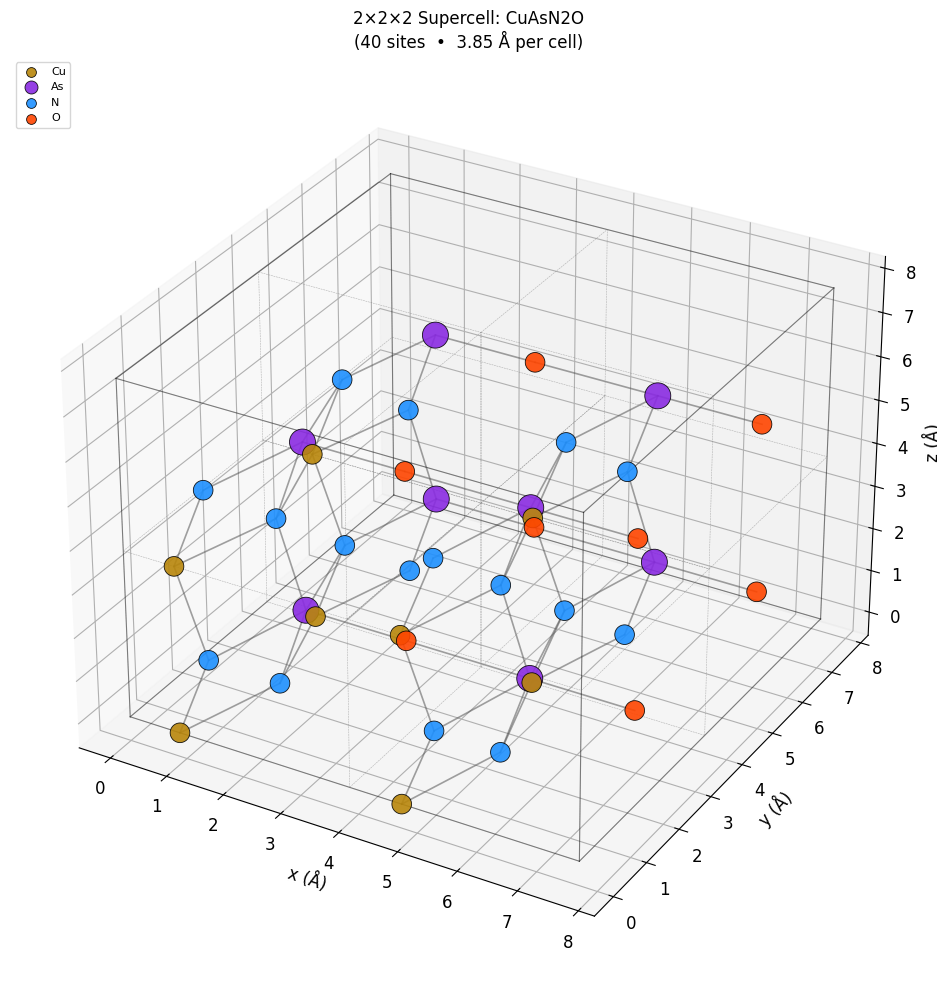


Unit cell bonds: 5  |  Supercell bonds: 60  |  Cutoff: 2.36 Å


In [26]:
# ========== Interactive: change ROW_ID and re-run this cell ==========
ROW_ID = 1111   # <-- change this to any index (0 to 18927)

s = df_raw.loc[ROW_ID, "structure"]
f = s.composition.reduced_formula
a = s.lattice.a
e = df_raw.loc[ROW_ID, "e_form"]
unique_els = list(dict.fromkeys(str(site.specie) for site in s))

print(f"Row {ROW_ID}: {f}  |  {len(unique_els)} elements: {unique_els}")
print(f"Lattice: a={a:.3f} Å  |  Sites: {len(s)}  |  e_form = {e:.2f} eV/atom\n")

# --- Single unit cell ---
fig = plt.figure(figsize=(9, 9))
ax  = fig.add_subplot(111, projection="3d")
nb, bc = draw_crystal(ax, s.copy(), s,
    f"Unit Cell: {f}\n(a = {a:.2f} Å  •  {len(s)} sites  •  e_form = {e:.2f} eV/atom)")
plt.tight_layout(); plt.show()

# --- 2×2×2 supercell ---
sc = s.copy(); sc.make_supercell([2, 2, 2])
fig2 = plt.figure(figsize=(10, 10))
ax2  = fig2.add_subplot(111, projection="3d")
nb2, bc2 = draw_crystal(ax2, sc, s,
    f"2×2×2 Supercell: {f}\n({len(sc)} sites  •  {a:.2f} Å per cell)",
    show_subcell_grid=True)
plt.tight_layout(); plt.show()

print(f"\nUnit cell bonds: {nb}  |  Supercell bonds: {nb2}  |  Cutoff: {bc:.2f} Å")

In [27]:
# ========== Feature count after featurization ==========
from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.structure.misc import StructureComposition
from matminer.featurizers.structure.matrix import SineCoulombMatrix

# Set up featurizers (same as training pipeline)
magpie_comp_     = ElementProperty.from_preset("magpie")
magpie_on_struct_ = StructureComposition(featurizer=magpie_comp_)
scm_             = SineCoulombMatrix(flatten=True)

# Use a small sample (10 rows) to check feature dimensions
sample_df = df_raw.head(10).copy()

# Fit SCM on the sample (needs to see structures to determine output shape)
scm_.fit(sample_df["structure"].tolist())

# Apply featurizers
sample_feat = magpie_on_struct_.featurize_dataframe(sample_df, col_id="structure",
                                                     ignore_errors=True, pbar=False)
n_magpie = len(sample_feat.columns) - len(sample_df.columns)

sample_feat = scm_.featurize_dataframe(sample_feat, col_id="structure",
                                        ignore_errors=True, pbar=False)
n_scm = len(sample_feat.columns) - len(sample_df.columns) - n_magpie

# Drop non-numeric + structure column
numeric_cols = sample_feat.drop(columns=["structure"], errors="ignore") \
                          .select_dtypes(include=[np.number]).columns

print("=" * 55)
print("Feature counts after featurization")
print("=" * 55)
print(f"  Magpie (composition stats) : {n_magpie:>4} features")
print(f"  SineCoulombMatrix (struct.) : {n_scm:>4} features")
print(f"  ─────────────────────────────────────")
print(f"  Total numeric features     : {len(numeric_cols):>4}")
print(f"  + target (e_form)          :    1")
print(f"  Dataset rows               : {len(df_raw):>5}")
print()
print("Sample Magpie features:", [c for c in sample_feat.columns if "MagpieData" in c][:5], "...")
print("Sample SCM features:   ", [c for c in sample_feat.columns if "sine coulomb" in c.lower()][:3], "...")

/usr/local/lib/python3.12/dist-packages/matminer/featurizers/structure/matrix.py:206: ComplexWarning: Casting complex values to real discards the imaginary part
  zeros[: len(eigs)] = eigs


Feature counts after featurization
  Magpie (composition stats) :  132 features
  SineCoulombMatrix (struct.) :    5 features
  ─────────────────────────────────────
  Total numeric features     :  138
  + target (e_form)          :    1
  Dataset rows               : 18928

Sample Magpie features: ['MagpieData minimum Number', 'MagpieData maximum Number', 'MagpieData range Number', 'MagpieData mean Number', 'MagpieData avg_dev Number'] ...
Sample SCM features:    ['sine coulomb matrix eig 0', 'sine coulomb matrix eig 1', 'sine coulomb matrix eig 2'] ...


In [ ]:
def drop_useless_features(X_train: pd.DataFrame,
                          X_test: pd.DataFrame,
                          near_const_frac: float = 0.99):
    """Drop columns that are all-zero, constant, or near-constant based on TRAIN only."""
    # All-zero
    all_zero = X_train.columns[(X_train == 0).all(axis=0)]

    # Constant (incl. all-NaN after featurization; handled later too)
    constant = X_train.columns[X_train.nunique(dropna=False) <= 1]

    # Near-constant by exact mode frequency (works best when values are truly repeated)
    near_constant = []
    n = len(X_train)
    for c in X_train.columns:
        vc = X_train[c].value_counts(dropna=False)
        if len(vc) > 0 and (vc.iloc[0] / n) >= near_const_frac:
            near_constant.append(c)

    drop_cols = set(all_zero) | set(constant) | set(near_constant)
    drop_cols = [c for c in X_train.columns if c in drop_cols]  # keep order

    X_train2 = X_train.drop(columns=drop_cols, errors="ignore")
    X_test2  = X_test.drop(columns=drop_cols, errors="ignore")
    return X_train2, X_test2, drop_cols


In [ ]:
def featurize(df: pd.DataFrame, is_train: bool):
    """Return df with features appended. Fits SCM on train structures per fold."""
    out = df.copy()

    # Fit SCM ONLY on train fold (good hygiene; also sets feature shape) :contentReference[oaicite:7]{index=7}
    if is_train:
        scm.fit(out["structure"].tolist())

    out = magpie_on_struct.featurize_dataframe(out, col_id="structure", ignore_errors=True, pbar=False)
    out = scm.featurize_dataframe(out, col_id="structure", ignore_errors=True, pbar=False)

    # Drop the raw structure column so it can't leak into the model
    out = out.drop(columns=["structure"], errors="ignore")
    return out


In [ ]:
def clean_and_align(train_df_feat: pd.DataFrame,
                    test_df_feat: pd.DataFrame,
                    target_col: str,
                    max_na_frac: float = 0.01):
    """Mimic the reference cleaning: drop too-NA columns, mean-impute."""
    # Keep only numeric columns (featurizers should be numeric, but this is defensive)
    X_train = train_df_feat.drop(columns=[target_col], errors="ignore").select_dtypes(include=[np.number])
    X_test  = test_df_feat.select_dtypes(include=[np.number])

    # Drop columns with too many NaNs based on training set
    na_frac = X_train.isna().mean()
    keep_cols = na_frac[na_frac <= max_na_frac].index
    X_train = X_train[keep_cols]
    X_test  = X_test[keep_cols]

    # Mean-impute using TRAIN means
    means = X_train.mean(numeric_only=True)
    X_train = X_train.fillna(means)
    X_test  = X_test.fillna(means)

    return X_train, X_test

In [ ]:
RANDOM_STATE = 42

# --- Featurizers: Magpie on structure composition + SineCoulombMatrix on structure ---
magpie_comp = ElementProperty.from_preset("magpie")  # Magpie preset exists in matminer :contentReference[oaicite:4]{index=4}
magpie_on_struct = StructureComposition(featurizer=magpie_comp)  # wrapper uses structure.composition :contentReference[oaicite:5]{index=5}
scm = SineCoulombMatrix(flatten=True)  # periodic Coulomb variant :contentReference[oaicite:6]{index=6}


# --- Load Matbench perovskites with official folds ---
mb = MatbenchBenchmark(autoload=False, subset=["matbench_perovskites"])
task = list(mb.tasks)[0]
task.load()

target = task.metadata.target  # should be "e_form" :contentReference[oaicite:8]{index=8}

fold_metrics = []
dropped_feature_counts = []

for fold in task.folds:
    df_train = task.get_train_and_val_data(fold, as_type="df")  # train+val per Matbench protocol
    df_test  = task.get_test_data(fold, include_target=True, as_type="df")

    # Featurize
    train_feat = featurize(df_train, is_train=True)
    test_feat  = featurize(df_test, is_train=False)

    # Separate target
    y_train = train_feat[target].values
    y_test  = test_feat[target].values

    # Clean / align / impute like the reference script
    X_train, X_test = clean_and_align(train_feat, test_feat, target_col=target, max_na_frac=0.01)

    # Your feature reduction: drop useless columns (all-zero / constant / >99% same)
    X_train, X_test, dropped_cols = drop_useless_features(X_train, X_test, near_const_frac=0.99)
    dropped_feature_counts.append(len(dropped_cols))

    # Model (RF baseline)
    model = RandomForestRegressor(
        n_estimators=500,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds)) # Calculate RMSE by taking the square root of MSE
    r2 = r2_score(y_test, preds)

    fold_metrics.append((mae, rmse, r2))
    print(f"Fold {fold}: MAE={mae:.4f} | RMSE={rmse:.4f} | R2={r2:.4f} | dropped={len(dropped_cols)}")

mae_mean = np.mean([m[0] for m in fold_metrics])
rmse_mean = np.mean([m[1] for m in fold_metrics])
r2_mean = np.mean([m[2] for m in fold_metrics])

print("\n=== CV Summary (matbench_perovskites) ===")
print(f"MAE : {mae_mean:.4f}")
print(f"RMSE: {rmse_mean:.4f}")
print(f"R2  : {r2_mean:.4f}")
print(f"Avg dropped features: {np.mean(dropped_feature_counts):.1f}")

2026-02-19 16:43:06 INFO     Initialized benchmark 'matbench_v0.1' with 1 tasks: 
['matbench_perovskites']


INFO:matbench:Initialized benchmark 'matbench_v0.1' with 1 tasks: 
['matbench_perovskites']


2026-02-19 16:43:06 INFO     Loading dataset 'matbench_perovskites'...


INFO:matbench.task:Loading dataset 'matbench_perovskites'...


2026-02-19 16:43:10 INFO     Dataset 'matbench_perovskites loaded.


...

Fold 0: MAE=0.2358 | RMSE=0.3300 | R2=0.7990 | dropped=20


/usr/local/lib/python3.12/dist-packages/matminer/featurizers/structure/matrix.py:206: ComplexWarning: Casting complex values to real discards the imaginary part
  zeros[: len(eigs)] = eigs
/usr/local/lib/python3.12/dist-packages/matminer/featurizers/structure/matrix.py:206: ComplexWarning: Casting complex values to real discards the imaginary part
  zeros[: len(eigs)] = eigs
/usr/local/lib/python3.12/dist-packages/matminer/featurizers/structure/matrix.py:206: ComplexWarning: Casting complex values to real discards the imaginary part
  zeros[: len(eigs)] = eigs
/usr/local/lib/python3.12/dist-packages/matminer/featurizers/structure/matrix.py:206: ComplexWarning: Casting complex values to real discards the imaginary part
  zeros[: len(eigs)] = eigs
/usr/local/lib/python3.12/dist-packages/matminer/featurizers/structure/matrix.py:206: ComplexWarning: Casting complex values to real discards the imaginary part
  zeros[: len(eigs)] = eigs
/usr/local/lib/python3.12/dist-packages/matminer/featur

Fold 1: MAE=0.2364 | RMSE=0.3388 | R2=0.8021 | dropped=20


/usr/local/lib/python3.12/dist-packages/matminer/featurizers/structure/matrix.py:206: ComplexWarning: Casting complex values to real discards the imaginary part
  zeros[: len(eigs)] = eigs
/usr/local/lib/python3.12/dist-packages/matminer/featurizers/structure/matrix.py:206: ComplexWarning: Casting complex values to real discards the imaginary part
  zeros[: len(eigs)] = eigs
/usr/local/lib/python3.12/dist-packages/matminer/featurizers/structure/matrix.py:206: ComplexWarning: Casting complex values to real discards the imaginary part
  zeros[: len(eigs)] = eigs
/usr/local/lib/python3.12/dist-packages/matminer/featurizers/structure/matrix.py:206: ComplexWarning: Casting complex values to real discards the imaginary part
  zeros[: len(eigs)] = eigs
/usr/local/lib/python3.12/dist-packages/matminer/featurizers/structure/matrix.py:206: ComplexWarning: Casting complex values to real discards the imaginary part
  zeros[: len(eigs)] = eigs
/usr/local/lib/python3.12/dist-packages/matminer/featur

Fold 2: MAE=0.2372 | RMSE=0.3381 | R2=0.7934 | dropped=20
